# Wind Forcing

In this Notebook, I create wind forcing based on ERA5 data. From ERA5, we get estimates of the 10m u and v wind speeds. 

In [48]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xmitgcm.utils

## Load Data

The data comes from here: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview

In [21]:
# load data
filepath = "/albedo/home/maschr005/data/ERA5/"
filename = "ERA5_2008_06-11_56-63S_0-16E_wind.grib"
filename_stress = "ERA5_2008_06-11_56-63S_0-16E_wind_stress.grib"


ds = xr.load_dataset(filepath+filename, engine="cfgrib")
ds_stress = xr.load_dataset(filepath+filename_stress, engine="cfgrib")

In [24]:
ds_stress

<xarray.Dataset> Size: 26MB
Dimensions:            (time: 4392, latitude: 15, longitude: 33)
Coordinates:
  * time               (time) datetime64[ns] 35kB 2008-06-01 ... 2008-11-30T2...
  * latitude           (latitude) float64 120B -56.0 -56.5 -57.0 ... -62.5 -63.0
  * longitude          (longitude) float64 264B 0.0 0.5 1.0 ... 15.0 15.5 16.0
    number             int64 8B 0
    step               timedelta64[ns] 8B 00:00:00
    meanSea            float64 8B 0.0
    valid_time         (time) datetime64[ns] 35kB 2008-06-01 ... 2008-11-30T2...
    heightAboveGround  float64 8B 10.0
Data variables:
    tauoc              (time, latitude, longitude) float32 9MB 0.9945 ... 0.9643
    dwi                (time, latitude, longitude) float32 9MB 325.9 ... 225.8
    wind               (time, latitude, longitude) float32 9MB 9.148 ... 6.998
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-21T13:56 GRIB to CDM+CF via cfgrib-0.9.1...

## July Cluster

In [35]:
start_date07 = pd.to_datetime("2008-07-16 00:00") # pd.to_datetime("2008-07-16 08:00")
end_date07 = pd.to_datetime("2008-07-19 23:59") # pd.to_datetime("2008-07-19 12:00")

ds07 = ds.sel(longitude = 8.75, latitude = -60.5, time = slice(start_date07,end_date07))
ds07_stress = ds_stress.sel(longitude = 9, latitude = -60.5, time = slice(start_date07,end_date07))


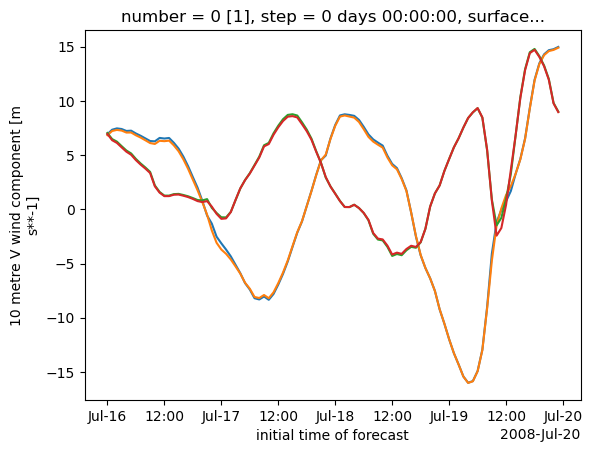

In [5]:
# compare neutral to standard wind speed
ds07.u10n.plot()
ds07.u10.plot()
ds07.v10n.plot()
ds07.v10.plot()

In [36]:
# calculate absolute wind speed
ds07["horizontal_speed"] = np.sqrt(ds07.u10**2 + ds07.v10**2)
ds07.horizontal_speed.attrs["lon_name"] = "10m horizontal wind speed"

# calculate angle
ds07["wind_dir"] = 180+np.arctan2(ds07.u10,ds07.v10)*180/np.pi

Mean horizontal wind speed 8.411048 m/s


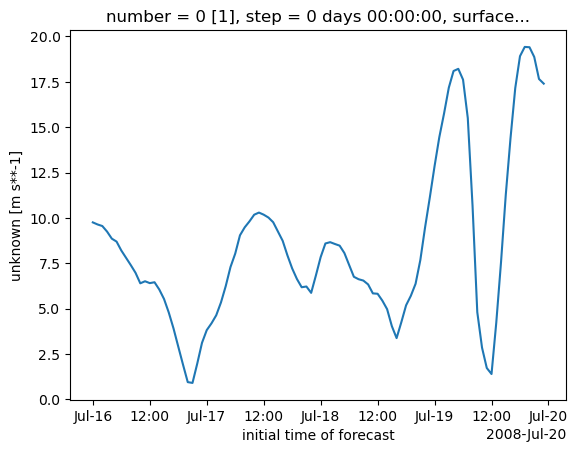

In [40]:
print("Mean horizontal wind speed", np.mean(np.abs(ds07.horizontal_speed.values)), "m/s")
ds07.horizontal_speed.plot()

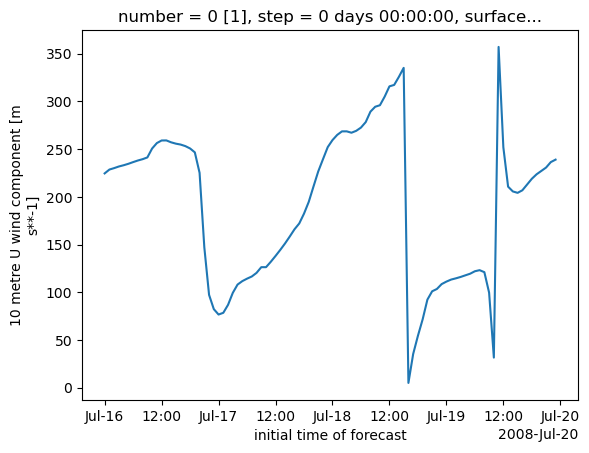

In [50]:
ds07.wind_dir.plot()

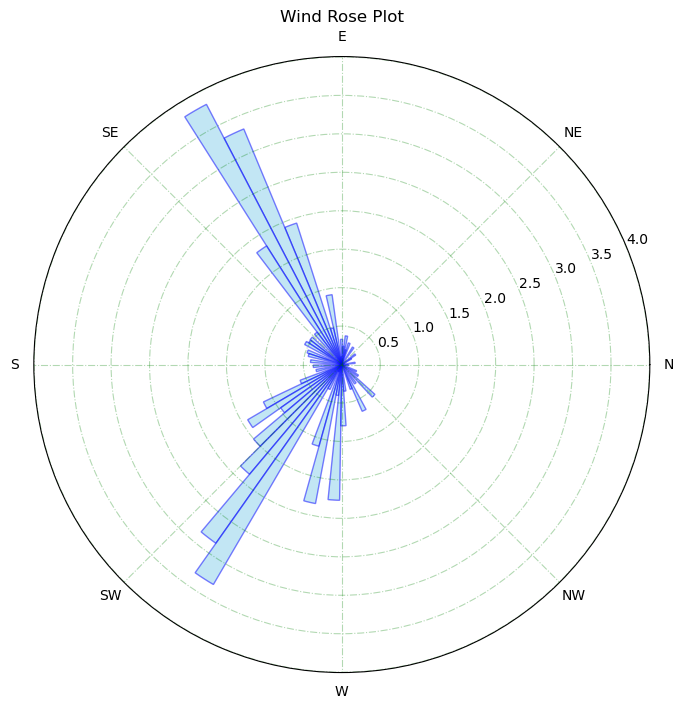

In [8]:
# wind rose

num_bins = 72
plt.figure(figsize=(8, 8))
ax = plt.subplot(polar=True)
weights = ds07.horizontal_speed / ds07.horizontal_speed.max()
bars = ax.hist(np.radians(ds07.wind_dir), bins=num_bins, weights=weights, 
               edgecolor='blue', color='skyblue', alpha=0.5)
ax.grid(True, linestyle='dashdot', alpha=0.3, color='green')
compass_labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
ax.set_xticks(np.linspace(0, 2*np.pi, len(compass_labels), endpoint=False))
ax.set_xticklabels(compass_labels)

plt.title('Wind Rose Plot')
plt.show()

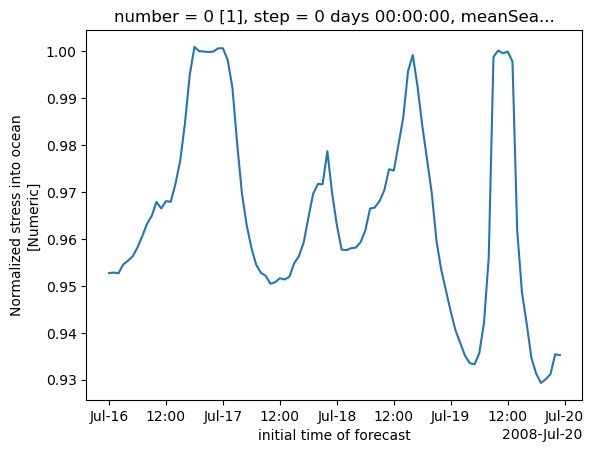

In [39]:
# ERA5 wind stress
ds07_stress.tauoc.plot()

## Calculate Wind Stress

The wind stess on the ocean 

$$ \tau = \rho_{air} C_{DN10} U^2_{N10}$$

$C_{DN10}$: Drag Coefficient for Neutral Stability at a height of $10m$. I use $C_{DN10} \approx 1.6e-3$ as an estimate. (see Elvidge et al., 2016, Fig. 10)

$\rho_{air} \approx 1.3\frac{kg}{m^3}$ air density


In [57]:
U_10m = 8 # wind speed at 10m above surface (m/s)

rho_air = 1.3 # kg/m^3
C_D = 1.6e-3

tau = rho_air * C_D * U_10m**2
print(f"Surface wind stress based on average wind speed of {U_10m} m/s: {tau:.2f} N/m^2")

Surface wind stress based on average wind speed of 8 m/s: 0.13 N/m^2


In [56]:
# calculate momentary stres
ds07["wind stress"] = rho_air * C_D * ds07.horizontal_speed**2
ds07["wind stress"].mean().values

array(0.21431957, dtype=float32)

## Create Binaries

I want to create zonal wind forcing. This will be fed into MITgcm through `zonalWindFile`. The zonal wind stress is specified on the U grid (YC, XG), however this isn't really relevant information for my uniform forcing. Apparently, for my constant forcing I can just provide a 2D file (?). Let's try this out

In [50]:
Nx = 50 # east-west
Ny = 100 # north south
t = 24*2 # forcing period in h
ice_edge = 50 # location of ice edge
buffer_size = 10 # length of buffer zone with no forcing in the north

tau0 = 0.19

tau_MIZ = np.zeros((Nx,Ny,t))
tau_MIZ[:,buffer_size:ice_edge,:] = tau0

# write binary
dir_binaries = "../../MITgcm/so_plumes/binaries/"
out_filename = "bin_forc_wind_zonal_" + f"Nx{Nx}_Ny{Ny}_t{t}_sharp-ice-edge" + f"_{tau0}Pa-const.bin"
xmitgcm.utils.write_to_binary(tau_MIZ.flatten(order='F'), dir_binaries + out_filename)
print(out_filename)

bin_forc_wind_zonal_Nx50_Ny100_t48_sharp-ice-edge_0.19Pa-const.bin
